In [3]:
import numpy as np

# input layer
X = np.array([[0, 0], [1, 0], [0, 1], [1, 1]])

# target outputs
y = np.array([[0], [1], [1], [0]])

# randomly generated weight matrices
W1 = np.random.randn(2, 4)
W2 = np.random.randn(4, 1)

# bias vectors
b1 = np.zeros((1, 4))
b2 = np.zeros((1, 1))

# sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# sigmoid derivative function
def sigmoid_der(x):
    return x * (1 - x)

# a single forward pass function
def forward_pass():
    hidden = X @ W1 + b1
    hidden_activated = sigmoid(hidden)

    output = hidden_activated @ W2 + b2
    output_activated = sigmoid(output)

    return hidden_activated, output_activated

# backpropagation function to update the weights and biases
def backward_pass(hidden_activated, output_activated, lr=0.5):
    global W1, W2, b1, b2
    n = X.shape[0]
    error = y - output_activated

    g1 = (1/n) * X.T @ ((error * sigmoid_der(output_activated)) @ W2.T * sigmoid_der(hidden_activated))
    g2 = (1/n) * hidden_activated.T @ (error * sigmoid_der(output_activated))

    g_b1 = (1/n) * np.sum((error * sigmoid_der(output_activated)) @ W2.T * sigmoid_der(hidden_activated), axis=0, keepdims=True)
    g_b2 = (1/n) * np.sum(error * sigmoid_der(output_activated), axis=0, keepdims=True)

    W1 += lr * g1
    W2 += lr * g2
    b1 += lr * g_b1
    b2 += lr * g_b2

# training loop
num_epochs = 50000
losses = []

for epoch in range(num_epochs):
    hidden_out, output_final = forward_pass()

    loss = np.mean((y - output_final) ** 2)
    losses.append(loss)

    backward_pass(hidden_out, output_final)

    if epoch % 1000 == 0:
        print(f"Epoch: {epoch}. Loss: {loss: .4f}")

hidden_out, output_final = forward_pass()
print("\nFinal predictions:")
print(np.round(output_final, 3))

Epoch: 0. Loss:  0.3331
Epoch: 1000. Loss:  0.2235
Epoch: 2000. Loss:  0.1227
Epoch: 3000. Loss:  0.0264
Epoch: 4000. Loss:  0.0099
Epoch: 5000. Loss:  0.0056
Epoch: 6000. Loss:  0.0039
Epoch: 7000. Loss:  0.0029
Epoch: 8000. Loss:  0.0023
Epoch: 9000. Loss:  0.0019
Epoch: 10000. Loss:  0.0016
Epoch: 11000. Loss:  0.0014
Epoch: 12000. Loss:  0.0012
Epoch: 13000. Loss:  0.0011
Epoch: 14000. Loss:  0.0010
Epoch: 15000. Loss:  0.0009
Epoch: 16000. Loss:  0.0008
Epoch: 17000. Loss:  0.0008
Epoch: 18000. Loss:  0.0007
Epoch: 19000. Loss:  0.0007
Epoch: 20000. Loss:  0.0006
Epoch: 21000. Loss:  0.0006
Epoch: 22000. Loss:  0.0006
Epoch: 23000. Loss:  0.0005
Epoch: 24000. Loss:  0.0005
Epoch: 25000. Loss:  0.0005
Epoch: 26000. Loss:  0.0005
Epoch: 27000. Loss:  0.0004
Epoch: 28000. Loss:  0.0004
Epoch: 29000. Loss:  0.0004
Epoch: 30000. Loss:  0.0004
Epoch: 31000. Loss:  0.0004
Epoch: 32000. Loss:  0.0004
Epoch: 33000. Loss:  0.0003
Epoch: 34000. Loss:  0.0003
Epoch: 35000. Loss:  0.0003
Epoch

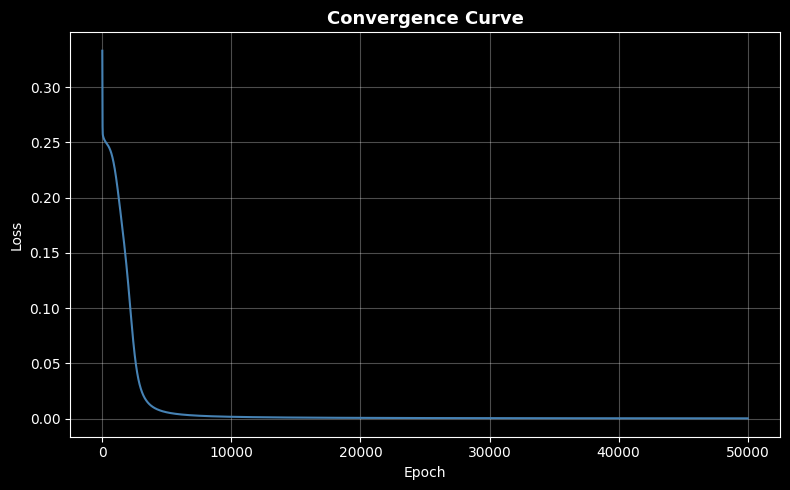

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(losses, color='steelblue', linewidth=1.5)
plt.title("Convergence Curve", fontsize=13, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

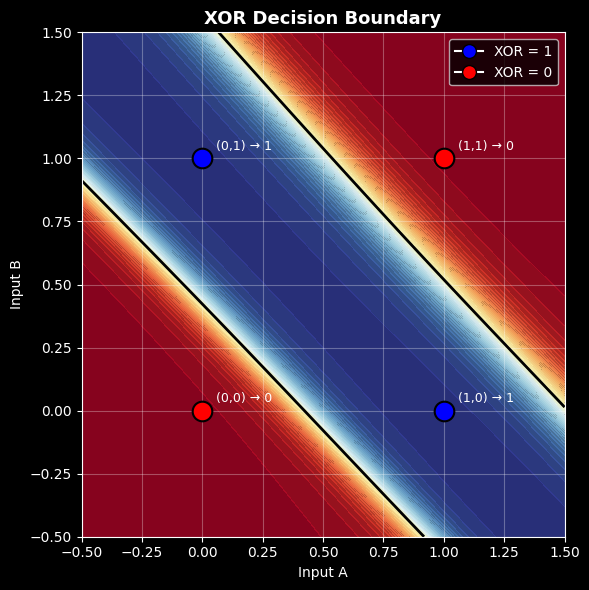

In [5]:
# ClaudeAI visualization

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# create a fine mesh over the input space
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300),
                     np.linspace(-0.5, 1.5, 300))

# flatten the mesh into a (90000, 2) matrix of points
grid = np.c_[xx.ravel(), yy.ravel()]

# run every grid point through the trained network
# forward_pass uses global X, so temporarily replace it
X_original = X
X = grid
grid_hidden_out, grid_output = forward_pass()
X = X_original

# reshape output back into the mesh shape
grid_output = grid_output.reshape(xx.shape)

# plot
fig, ax = plt.subplots(figsize=(6, 6))

# color the background by predicted probability
ax.contourf(xx, yy, grid_output, levels=50, cmap='RdYlBu', alpha=0.8)

# draw the decision boundary at 0.5
ax.contour(xx, yy, grid_output, levels=[0.5], colors='black', linewidths=2)

# plot the 4 XOR points
colors = ['red' if label == 0 else 'blue' for label in y.ravel()]
for i in range(len(X_original)):
    ax.scatter(X_original[i][0], X_original[i][1],
               color=colors[i], s=200, zorder=5,
               edgecolors='black', linewidths=1.5)
    ax.annotate(f"({X_original[i][0]},{X_original[i][1]}) → {y[i][0]}",
                (X_original[i][0], X_original[i][1]),
                textcoords="offset points", xytext=(10, 6), fontsize=9)

# legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
           markersize=10, markeredgecolor='black', label='XOR = 1'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=10, markeredgecolor='black', label='XOR = 0')
]
ax.legend(handles=legend_elements)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel("Input A")
ax.set_ylabel("Input B")
ax.set_title("XOR Decision Boundary", fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

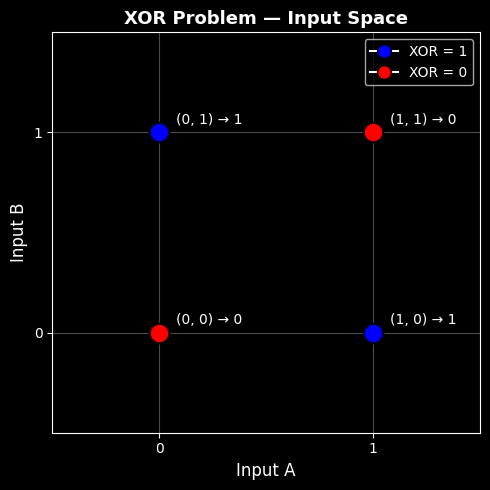

In [6]:
# ClaudeAI visualization

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

colors = ['red' if label == 0 else 'blue' for label in y]

fig, ax = plt.subplots(figsize=(5, 5))

for i in range(len(X)):
    ax.scatter(X[i][0], X[i][1], color=colors[i], s=200, edgecolors='black', linewidths=1.5, zorder=5)
    ax.annotate(f"({X[i][0]}, {X[i][1]}) → {y[i]}",
                (X[i][0], X[i][1]),
                textcoords="offset points", xytext=(12, 6), fontsize=10)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
           markersize=10, markeredgecolor='black', label='XOR = 1'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=10, markeredgecolor='black', label='XOR = 0')
]
ax.legend(handles=legend_elements, fontsize=10)

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel("Input A", fontsize=12)
ax.set_ylabel("Input B", fontsize=12)
ax.set_title("XOR Problem — Input Space", fontsize=13, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("xor_inputs.png", dpi=150, bbox_inches='tight')
plt.show()